In [1]:
# Each .dat file is a Python dictionary with two main keys

# subject['data'] → THE EEG & physiological signals
# Shape : (40, 40, 8064) → 40 videos, 40 channels, 8064 time samples
# Channels 0–31 → EEG electrodes
# Channels 32–39 → peripheral signals (GSR, ECG, respiration, etc.)
# 128 Hz, 8064 → 63 seconds


# subject['labels'] → emotional self-reports
# Shape : (40, 4)
# For each video [valence, arousal, dominance, liking]
# Each value ∈ [1, 9]


In [2]:
# Valence :  Positivy vs Negativity (DO I LIKE THIS FEELING OR NOT)
# Arousal : Excitement vs Calm 
# Dominance : Control (usually we don't want the user to be in control when it comes to marketing)
# Liking : Preference (Will I buy or not)

In [3]:
# 32	hEOG	Horizontal Eye Movement	Left/Right glances. Mostly noise/artifacts.
# 33	vEOG	Vertical Eye Movement	Blinking/Up-Down. Mostly noise/artifacts.

# 34	zEMG	Zygomaticus Major EMG	Smiling Muscle. Detects subtle smiles.
# 35	tEMG	Trapezius EMG	Neck Tension. Detects stress/head movement.
# 36	GSR	Galvanic Skin Response	Sweat/Arousal. Key for emotional intensity.
# 37	Respiration	Respiration Belt	Breathing speed. Slow = Calm, Fast = Excited.
# 38    BVP	Plethysmograph	Heart Rate/Blood Volume.
# 39	Temp	Temperature	Skin temp. (Usually slow to change)..

The goal is to create model and a map where we classify for range of the values (Valence, Arousal) that will make the Liking being higher for a certain type of ad.

In [2]:
import sys
print(sys.executable)          # which Python/env is the kernel using?
print([p for p in sys.path if 'numpy' in p.lower()])  # any numpy source in path?

import importlib.util
spec = importlib.util.find_spec("numpy")
print(spec.origin)             # where is numpy being loaded FROM?


c:\ProgramData\anaconda3\python.exe
[]
C:\Users\axelo\AppData\Roaming\Python\Python312\site-packages\numpy\__init__.py


In [1]:
import os
import time
import math
import keras
import timeit
import warnings
import csv

import numpy as np
import numpy as np
from scipy.signal import welch
import pickle as pickle
import pandas as pd
import keras.backend as K
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, normalize
from tensorflow.keras.callbacks import Callback
from keras.models import Sequential, Model
from keras.regularizers import l2
from keras.optimizers import SGD
from keras.layers import (
    Dense, Conv1D, MaxPooling1D, 
    Conv2D, MaxPooling2D, Dropout,
    Flatten, Convolution1D, ZeroPadding1D, LSTM,
    BatchNormalization, Activation, Bidirectional
)

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pickle # To save the model for later

In [2]:
def bin_power_scipy(signal, band, sf):
    """
    Replacement for pe.bin_power
    Returns (band_powers, total_power)
    """
    freqs, psd = welch(signal, sf, nperseg=len(signal))
    
    band_powers = []
    for low, high in band:
        idx = np.logical_and(freqs >= low, freqs <= high)
        power = np.trapz(psd[idx], freqs[idx])
        band_powers.append(power)

    total_power = np.sum(band_powers)
    return np.array(band_powers), total_power


In [3]:
channel = [1,2,3,4,6,11,13,17,19,20,21,25,29,31] # 14 channels

band = [4,8,12,16,25,45]

bands = [
    (4,8),
    (8,12),
    (12,16),
    (16,25),
    (25,45)
]

window_size = 256  # 2 sec window at 128 Hz
step_size   = 16   # 0.125 sec step
sample_rate = 128

# All 32 subjects
subjectList = [f'{i:02d}' for i in range(1, 33)]

In [4]:
def fft_processing(subject, channel, band, window_size, step_size, sample_rate):

    path = r"E:\COURS ECOLE\COURS PGE 4\AI CLINIC\data\deap-dataset"

    with open(f'{path}\\data_preprocessed_python\\s{subject}.dat', 'rb') as file:
        subject_data = pickle.load(file, encoding='latin1')

    bands = [(band[i], band[i+1]) for i in range(len(band)-1)]

    meta = []

    for trial in range(40):
        data = subject_data["data"][trial]
        labels = subject_data["labels"][trial]
        start = 0

        while start + window_size < data.shape[1]:
            meta_data = []

            for ch in channel:
                X = data[ch][start : start + window_size]
                Y, _ = bin_power_scipy(X, bands, sample_rate)
                meta_data.extend(Y)

            meta.append([np.array(meta_data), labels])
            start += step_size

    meta = np.array(meta, dtype=object)


    np.save(f's{subject}_processed.npy', meta, allow_pickle=True)


In [5]:
import os

data_dir = r"E:\COURS ECOLE\COURS PGE 4\AI CLINIC\data\deap-dataset\data_preprocessed_python"

for subject in subjectList:
    out_file = f's{subject}_processed.npy'
    if os.path.exists(out_file):
        print(f"[SKIP] s{subject} — already processed")
        continue
    print(f"[PROC] s{subject}…", end=' ', flush=True)
    fft_processing(subject, channel, band, window_size, step_size, sample_rate)
    print("done")

print("\nAll subjects processed.")

[SKIP] s01 — already processed
[SKIP] s02 — already processed
[SKIP] s03 — already processed
[SKIP] s04 — already processed
[SKIP] s05 — already processed
[SKIP] s06 — already processed
[PROC] s07… 

C:\Users\axelo\AppData\Local\Temp\ipykernel_10084\1459989710.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  power = np.trapz(psd[idx], freqs[idx])


done
[PROC] s08… done
[PROC] s09… done
[PROC] s10… done
[PROC] s11… done
[PROC] s12… done
[PROC] s13… done
[PROC] s14… done
[PROC] s15… done
[PROC] s16… done
[PROC] s17… done
[PROC] s18… done
[PROC] s19… done
[PROC] s20… done
[PROC] s21… done
[PROC] s22… done
[PROC] s23… done
[PROC] s24… done
[PROC] s25… done
[PROC] s26… done
[PROC] s27… done
[PROC] s28… done
[PROC] s29… done
[PROC] s30… done
[PROC] s31… done
[PROC] s32… done

All subjects processed.


In [9]:


# --- 1. Load Your Processed Data ---
subject_id = '01' # Change to match the file you created
data_file = f's{subject_id}_processed.npy'

print(f"Loading {data_file}...")
# Allow_pickle is needed because you saved it as an object array
meta_data = np.load(data_file, allow_pickle=True)

# --- 2. Separate Features (X) and Labels (y) ---
# Your structure is: [ [Features_Array, Labels_Array], [Features_Array, Labels_Array], ... ]

# Stack the features into a clean matrix
# This converts a list of arrays into one big 2D array
X = np.vstack(meta_data[:, 0]) 

# Stack the labels
y_raw = np.vstack(meta_data[:, 1])

# --- 3. Define "Purchase Intent" (The Target) ---
# In DEAP, labels are: [Valence, Arousal, Dominance, Liking]
# We want 'Liking' (Index 3).
liking_scores = y_raw[:, 3]

# THRESHOLD: If Liking > 5, we classify as "Buy" (1). Otherwise "No Buy" (0).
y = (liking_scores > 5.0).astype(int)

print(f"Feature Shape: {X.shape}") # (Num_Windows, Num_Features)
print(f"Target Shape: {y.shape}")  # (Num_Windows,)
print(f"Buy/No-Buy Ratio: {np.sum(y)} / {len(y)}") # Check if classes are balanced



# --- 4. Split Data ---
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- NEW STEP: Normalization ---
scaler = StandardScaler()

# Fit on training data ONLY to avoid data leakage
X_train_scaled = scaler.fit_transform(X_train)
# Apply the same scaling to the test data
X_test_scaled = scaler.transform(X_test)

# --- Train Model with SCALED data ---
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)

# --- Evaluate ---
y_pred = clf.predict(X_test_scaled)

# --- 5. Train the Model ---
# Random Forest is excellent for EEG because it handles non-linear relationships well
print("Training Model (this might take a moment)...")
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# --- 6. Evaluate ---
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("-" * 30)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("-" * 30)
print("Detailed Report:")
print(classification_report(y_test, y_pred))

# --- 7. Save the Model (For the Arduino Project) ---
with open('neuromarketing_model.pkl', 'wb') as f:
    pickle.dump(clf, f)
    print("Model saved as 'neuromarketing_model.pkl'")

Loading s01_processed.npy...
Feature Shape: (19520, 70)
Target Shape: (19520,)
Buy/No-Buy Ratio: 18544 / 19520
Training Model (this might take a moment)...
------------------------------
Model Accuracy: 98.13%
------------------------------
Detailed Report:
              precision    recall  f1-score   support

           0       1.00      0.56      0.72       167
           1       0.98      1.00      0.99      3737

    accuracy                           0.98      3904
   macro avg       0.99      0.78      0.86      3904
weighted avg       0.98      0.98      0.98      3904

Model saved as 'neuromarketing_model.pkl'


In [11]:
meta_data.shape

(19520, 2)

In [ ]:
path = r"E:\COURS ECOLE\COURS PGE 4\AI CLINIC\data\deap-dataset"
data = {}
with open(f'{path}\\data_preprocessed_python\\s01.dat', 'rb') as file:
        subject_data = pickle.load(file, encoding='latin1')
        labels = subject_data["labels"]

        for vid_id  in labels.shape[0]:
                data[vid_id] = [np.mean(labels)]
        print(subject_data["data"].shape)
        print(subject_data["labels"].shape) # 1 Valence, # 2 Arousal, # Dominance, # Liking

(40, 40, 8064)
(40, 4)


In [18]:
data_dir = r"E:\COURS ECOLE\COURS PGE 4\AI CLINIC\data\deap-dataset\data_preprocessed_python"
filenames = [f"s{i:02d}.dat" for i in range(1, 33)]

all_labels = []

for filename in filenames:
    filepath = os.path.join(data_dir, filename)

    with open(filepath, "rb") as file:
        subject_data = pickle.load(file, encoding="latin1")
        all_labels.append(subject_data["labels"])


all_labels_np = np.array(all_labels)
mean_ratings = np.mean(all_labels_np, axis=0)

In [20]:
df_videos = pd.DataFrame(mean_ratings, columns=['Mean_Valence', 'Mean_Arousal', 'Mean_Dominance', 'Mean_Liking'])
df_videos['Video_ID'] = range(1, 41)

val_threshold = df_videos['Mean_Valence'].median()
aro_threshold = df_videos['Mean_Arousal'].median()

print(f"New Valence Threshold: {val_threshold:.2f}")
print(f"New Arousal Threshold: {aro_threshold:.2f}")

# 2. APPLY RELATIVE CLASSIFICATION
def classify_relative(row):
    # We compare against the group median, not 5.0
    v = row['Mean_Valence']
    a = row['Mean_Arousal']
    
    if v >= val_threshold and a >= aro_threshold:
        return "Action/High-Octane"      # Above avg V, Above avg A
    elif v >= val_threshold and a < aro_threshold:
        return "Sentimental/Warm"        # Above avg V, Below avg A
    elif v < val_threshold and a >= aro_threshold:
        return "Fear/Problem-Solution"   # Below avg V, Above avg A
    else:
        return "Melancholic/Serious"     # Below avg V, Below avg A

df_videos['Ad_Class'] = df_videos.apply(classify_relative, axis=1)

# 3. CHECK THE NEW BALANCE
print("\n--- New Distribution (Guaranteed Balanced) ---")
print(df_videos['Ad_Class'].value_counts())

New Valence Threshold: 3.35
New Arousal Threshold: 3.40

--- New Distribution (Guaranteed Balanced) ---
Ad_Class
Melancholic/Serious      10
Sentimental/Warm         10
Action/High-Octane       10
Fear/Problem-Solution    10
Name: count, dtype: int64


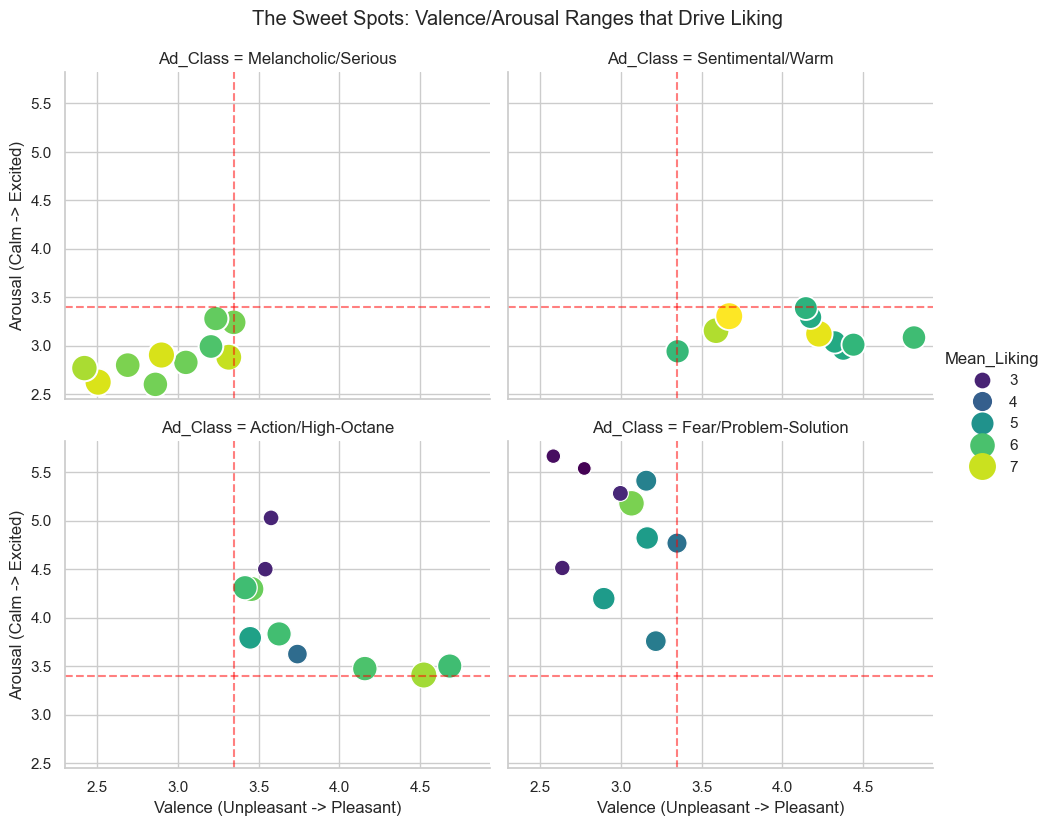

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a style
sns.set(style="whitegrid")

# Create the FacetGrid
# We map 'Ad_Class' to columns so we get 4 side-by-side plots
g = sns.relplot(
    data=df_videos,
    x="Mean_Valence", 
    y="Mean_Arousal",
    col="Ad_Class",          # Split by Class
    hue="Mean_Liking",       # Color intensity = Liking
    size="Mean_Liking",      # Dot size = Liking
    palette="viridis",       # Yellow/Green = High Liking, Purple = Low
    sizes=(100, 400),
    col_wrap=2,              # 2 plots per row
    height=4, 
    aspect=1.2
)

# Add title and adjust
g.fig.suptitle('The Sweet Spots: Valence/Arousal Ranges that Drive Liking', y=1.03)
g.set_axis_labels("Valence (Unpleasant -> Pleasant)", "Arousal (Calm -> Excited)")

# Draw the Median lines again for reference
for ax in g.axes.flatten():
    ax.axhline(aro_threshold, color='red', linestyle='--', alpha=0.5)
    ax.axvline(val_threshold, color='red', linestyle='--', alpha=0.5)

plt.show()

In [22]:
print("--- OPTIMAL RANGES PER CLASS ---")

for ad_class in df_videos['Ad_Class'].unique():
    # Filter for the specific class
    subset = df_videos[df_videos['Ad_Class'] == ad_class]
    
    # Filter for the "Top Performers" (Top 25% of Liking scores in this class)
    top_performers = subset[subset['Mean_Liking'] >= subset['Mean_Liking'].quantile(0.75)]
    
    print(f"\nCategory: {ad_class}")
    print(f"  > To maximize Liking, aim for:")
    print(f"  > Valence between: {top_performers['Mean_Valence'].min():.2f} and {top_performers['Mean_Valence'].max():.2f}")
    print(f"  > Arousal between: {top_performers['Mean_Arousal'].min():.2f} and {top_performers['Mean_Arousal'].max():.2f}")
    print(f"  > (Based on {len(top_performers)} top performing videos)")

--- OPTIMAL RANGES PER CLASS ---

Category: Melancholic/Serious
  > To maximize Liking, aim for:
  > Valence between: 2.51 and 3.31
  > Arousal between: 2.63 and 2.91
  > (Based on 3 top performing videos)

Category: Sentimental/Warm
  > To maximize Liking, aim for:
  > Valence between: 3.59 and 4.23
  > Arousal between: 3.12 and 3.31
  > (Based on 3 top performing videos)

Category: Action/High-Octane
  > To maximize Liking, aim for:
  > Valence between: 3.45 and 4.52
  > Arousal between: 3.41 and 4.30
  > (Based on 3 top performing videos)

Category: Fear/Problem-Solution
  > To maximize Liking, aim for:
  > Valence between: 2.89 and 3.16
  > Arousal between: 4.20 and 5.18
  > (Based on 3 top performing videos)


Now the next stpe for me is I think train a model to predict simultaneously Valence and Arousal



and also which can tells us how far we are from the range of values that we need based on the type of ad. So a sort of score which tend to be close to 0 when we are in the range



The only data that we have regarding consumer is the Liking variable which can be associated to the click of the user. The objective remains maximizing the liking.
The question is now to create a system which can convert brain signals into tokens so that we can feed a transformer for that.
Since we have the label interval which can maximize the licking based on the type of the Ad, we can use that to guide the LLM throughout its learning. 

In [ ]:
# IMRF, MEG, ISPIFS

# STEP 1 — Fix Class Imbalance

The 98% accuracy was misleading: 95% of windows were labeled "Buy", so the model just learned to always predict Buy.

**Fix:** use `class_weight='balanced'` so the model penalizes errors on the minority class proportionally, and lower the decision threshold from 0.5 to something more appropriate.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pickle

# --- Load data (subject 01) ---
meta_data = np.load('s01_processed.npy', allow_pickle=True)
X = np.vstack(meta_data[:, 0])
y_raw = np.vstack(meta_data[:, 1])

liking_scores = y_raw[:, 3]
y = (liking_scores > 5.0).astype(int)

print(f"Class distribution — Buy: {np.sum(y)} | No-Buy: {len(y) - np.sum(y)}")
print(f"Imbalance ratio: {np.sum(y) / len(y) * 100:.1f}% positive class\n")

# --- Train/test split + scaling ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# --- Balanced Random Forest ---
clf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',   # key fix: weights inversely proportional to class freq
    random_state=42,
    n_jobs=-1
)
clf_balanced.fit(X_train_s, y_train)

# --- Threshold tuning: find the threshold maximising F1 on test set ---
from sklearn.metrics import f1_score
proba = clf_balanced.predict_proba(X_test_s)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_test, (proba >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best threshold (max F1): {best_threshold:.2f}\n")

y_pred_balanced = (proba >= best_threshold).astype(int)

# --- Results ---
print("=" * 50)
print(f"Accuracy : {accuracy_score(y_test, y_pred_balanced)*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, proba):.4f}  ← real performance metric")
print("=" * 50)
print(classification_report(y_test, y_pred_balanced, target_names=["No-Buy", "Buy"]))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

# Save balanced model + scaler
with open('neuromarketing_model_balanced.pkl', 'wb') as f:
    pickle.dump({'model': clf_balanced, 'scaler': scaler, 'threshold': best_threshold}, f)
print("\nSaved: neuromarketing_model_balanced.pkl")

# STEP 2 — Multi-Subject Regression: Predict Valence & Arousal Simultaneously

Instead of a binary classifier, we now train a regression model that outputs a **2D emotional state vector [Valence, Arousal]** from EEG features.

- Input: 70 EEG band-power features (14 channels × 5 bands)
- Output: [Valence, Arousal] ∈ [1, 9]²
- Data: all subjects for whom we have processed .npy files
- Model: Multi-output Random Forest (good baseline before going neural)

In [ ]:
import os
import glob
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# --- 1. Load all available processed subjects ---
npy_files = glob.glob('s*_processed.npy')
print(f"Found processed files: {npy_files}\n")

all_X, all_y = [], []

for f in npy_files:
    d = np.load(f, allow_pickle=True)
    X_sub = np.vstack(d[:, 0])
    y_sub = np.vstack(d[:, 1])           # shape (N, 4): [Valence, Arousal, Dominance, Liking]
    # Add subject ID as extra feature to let the model learn inter-subject variance
    sub_id = int(f.replace('s', '').replace('_processed.npy', ''))
    sub_col = np.full((X_sub.shape[0], 1), sub_id)
    all_X.append(np.hstack([X_sub, sub_col]))
    all_y.append(y_sub[:, :2])            # keep only [Valence, Arousal]

X_all = np.vstack(all_X)
y_all = np.vstack(all_y)

print(f"Total windows: {X_all.shape[0]}")
print(f"Features per window: {X_all.shape[1]}  (70 EEG + 1 subject ID)")
print(f"Targets shape: {y_all.shape}  [Valence, Arousal]\n")

# --- 2. Split & scale ---
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

scaler_reg = StandardScaler()
X_train_s = scaler_reg.fit_transform(X_train)
X_test_s  = scaler_reg.transform(X_test)

# --- 3. Multi-output Random Forest Regressor ---
base_rf  = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
multi_rf = MultiOutputRegressor(base_rf)

print("Training multi-output regressor… (may take ~1 min)")
multi_rf.fit(X_train_s, y_train)

# --- 4. Evaluate ---
y_pred = multi_rf.predict(X_test_s)

mse_v  = mean_squared_error(y_test[:, 0], y_pred[:, 0])
mse_a  = mean_squared_error(y_test[:, 1], y_pred[:, 1])
r2_v   = r2_score(y_test[:, 0], y_pred[:, 0])
r2_a   = r2_score(y_test[:, 1], y_pred[:, 1])

print("\n=== Regression Results ===")
print(f"Valence  — MSE: {mse_v:.4f} | R²: {r2_v:.4f}")
print(f"Arousal  — MSE: {mse_a:.4f} | R²: {r2_a:.4f}")

# --- 5. Visualise predictions vs ground truth ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, dim, label in zip(axes, [0, 1], ['Valence', 'Arousal']):
    ax.scatter(y_test[:, dim], y_pred[:, dim], alpha=0.1, s=5)
    lims = [1, 9]
    ax.plot(lims, lims, 'r--', label='Perfect')
    ax.set_xlabel(f'True {label}')
    ax.set_ylabel(f'Predicted {label}')
    ax.set_title(f'{label} — R²={r2_score(y_test[:,dim], y_pred[:,dim]):.3f}')
    ax.legend()
plt.tight_layout()
plt.show()

# --- 6. Save model + scaler ---
with open('va_regressor.pkl', 'wb') as f:
    pickle.dump({'model': multi_rf, 'scaler': scaler_reg}, f)
print("\nSaved: va_regressor.pkl")

# STEP 3 — Real-Time Alignment Score: Distance to Optimal Zone

Given a predicted [Valence, Arousal] state and a target ad category, compute how far the user's brain state is from the **optimal zone** identified earlier.

- Score = 0 → user is perfectly inside the optimal zone for this ad → run the ad
- Score → 1 → user is far from the zone → switch ad category

The distance is normalized so scores are comparable across categories.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# --- 1. Optimal zones from the earlier analysis ---
# Format: { category: (valence_min, valence_max, arousal_min, arousal_max) }
OPTIMAL_ZONES = {
    "Action/High-Octane":    (3.45, 4.52, 3.41, 4.30),
    "Sentimental/Warm":      (3.59, 4.23, 3.12, 3.31),
    "Fear/Problem-Solution": (2.89, 3.16, 4.20, 5.18),
    "Melancholic/Serious":   (2.51, 3.31, 2.63, 2.91),
}

def alignment_score(valence: float, arousal: float, ad_category: str) -> float:
    """
    Returns a score in [0, 1].
    0  = brain state is inside the optimal zone  (perfect match)
    >0 = normalised distance to the nearest edge of the zone
    1  = far from the zone (max observed distance across the V/A space)
    """
    v_min, v_max, a_min, a_max = OPTIMAL_ZONES[ad_category]

    # Distance to box: 0 when inside, positive when outside
    dv = max(v_min - valence, 0, valence - v_max)   # horizontal gap
    da = max(a_min - arousal, 0, arousal - a_max)   # vertical gap
    raw_dist = np.sqrt(dv**2 + da**2)

    # Normalise by the diagonal of the full V/A space [1,9]×[1,9]
    max_possible = np.sqrt(8**2 + 8**2)
    return float(np.clip(raw_dist / max_possible, 0.0, 1.0))


def recommend_ad(valence: float, arousal: float) -> dict:
    """Returns the best ad category and alignment scores for all categories."""
    scores = {cat: alignment_score(valence, arousal, cat) for cat in OPTIMAL_ZONES}
    best   = min(scores, key=scores.get)
    return {"recommended": best, "scores": scores}


# --- 2. Quick unit tests ---
test_cases = [
    (4.0, 3.8, "Action/High-Octane"),     # inside action zone
    (3.9, 3.2, "Sentimental/Warm"),        # inside sentimental zone
    (3.0, 4.7, "Fear/Problem-Solution"),   # inside fear zone
    (2.9, 2.7, "Melancholic/Serious"),     # inside melancholic zone
    (1.0, 1.0, None),                      # corner, should pick nearest
]

print("=== Alignment Score Tests ===\n")
for v, a, expected in test_cases:
    result = recommend_ad(v, a)
    match  = "✓" if result["recommended"] == expected else "?"
    print(f"V={v:.1f} A={a:.1f} → recommended: {result['recommended']}  {match}")
    for cat, score in result["scores"].items():
        bar = "█" * int((1 - score) * 20)
        print(f"    {cat:<30} score={score:.3f}  alignment |{bar:<20}|")
    print()

# --- 3. Visualise the optimal zones + score heatmap for one category ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

v_grid = np.linspace(1, 9, 200)
a_grid = np.linspace(1, 9, 200)
VV, AA = np.meshgrid(v_grid, a_grid)

colors = {"Action/High-Octane": "gold", "Sentimental/Warm": "coral",
          "Fear/Problem-Solution": "mediumpurple", "Melancholic/Serious": "steelblue"}

# Left: zone map
ax = axes[0]
ax.set_facecolor('#f8f8f8')
for cat, (v_min, v_max, a_min, a_max) in OPTIMAL_ZONES.items():
    rect = mpatches.FancyBboxPatch(
        (v_min, a_min), v_max - v_min, a_max - a_min,
        boxstyle="round,pad=0.05", linewidth=2,
        edgecolor='black', facecolor=colors[cat], alpha=0.6, label=cat
    )
    ax.add_patch(rect)
    ax.text((v_min + v_max) / 2, (a_min + a_max) / 2, cat,
            ha='center', va='center', fontsize=7, fontweight='bold')

ax.set_xlim(1, 9); ax.set_ylim(1, 9)
ax.set_xlabel("Valence"); ax.set_ylabel("Arousal")
ax.set_title("Optimal Zones per Ad Category")

# Right: alignment score heatmap for "Action/High-Octane"
target_cat = "Action/High-Octane"
score_map = np.vectorize(lambda v, a: alignment_score(v, a, target_cat))(VV, AA)

im = axes[1].contourf(VV, AA, score_map, levels=50, cmap='RdYlGn_r')
plt.colorbar(im, ax=axes[1], label='Alignment Score (0=perfect)')
axes[1].set_xlabel("Valence"); axes[1].set_ylabel("Arousal")
axes[1].set_title(f'Alignment Score Heatmap\n→ "{target_cat}"')

# Mark the zone boundary
v_min, v_max, a_min, a_max = OPTIMAL_ZONES[target_cat]
rect = mpatches.FancyBboxPatch(
    (v_min, a_min), v_max - v_min, a_max - a_min,
    boxstyle="round,pad=0.02", linewidth=2,
    edgecolor='black', facecolor='none'
)
axes[1].add_patch(rect)

plt.tight_layout()
plt.show()

# --- 4. Save the scoring functions for real-time use ---
import pickle
with open('alignment_scorer.pkl', 'wb') as f:
    pickle.dump({'optimal_zones': OPTIMAL_ZONES,
                 'alignment_score': alignment_score,
                 'recommend_ad': recommend_ad}, f)
print("Saved: alignment_scorer.pkl")